In [ ]:
import pandas as pd
import seaborn as sns
import os
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
import datetime as dt

In [ ]:
# EDA, BVP and TEMP data already clean (from what I can see), automated cleaning of first two rows and addition of "time" column. Result sent to clenaed folder.
directory='../dataset/raw/e4'
for filename in os.listdir(directory):
    f = os.path.join(directory, filename)
    if not(os.path.isfile(f)):
        for file in os.listdir(f):
            filename = os.path.join(f, file)
            path = filename.split('/')
            name = path[len(path) - 1]
            if name == "EDA.csv" or name == "BVP.csv" or name == "TEMP.csv":
                variable = ''
                if name == "EDA.csv":
                    variable = 'EDA'
                elif name == "BVP.csv":
                    variable = 'BVP'
                else:
                    variable = 'TEMP'
                username = path[len(path) - 2]
                user_data = pd.read_csv(str(filename))
                start_time = list(user_data.columns.values)
                user_data.rename(columns={start_time[0]:variable}, inplace=True)
                frequency = user_data[variable][0]
                user_data.drop([0], inplace=True)
                t = {'time':[]}
                user_data.index -= 1
                t['time'] = user_data.index
                time_df = pd.DataFrame(data=t)
                time_column = time_df.apply(lambda x: x*(1/frequency), axis=0)
                user_data.index = time_column['time']
                if name == "EDA.csv":
                    user_data.to_csv('../dataset/cleaned/' + username + '_EDA.csv')
                elif name == "BVP.csv":
                    user_data.to_csv('../dataset/cleaned/' + username + '_BVP.csv')
                elif name == "TEMP.csv":
                    user_data.to_csv('../dataset/cleaned/' + username + '_TEMP.csv')

In [ ]:
# Started analyzing IBI data. Next step trying to fill the "holes" in the data in an automated way and then send the resulting files to the cleaned folder.
IBI = pd.read_csv('../dataset/raw/e4/B20_210514-114112/IBI.csv')
IBI.head(10)
IBI.rename(columns={'1620992472.000000':'timestamp', ' IBI':'IBI'}, inplace=True)
IBI.head(10)
IBI['PREV'] = IBI['timestamp'].shift(1)
IBI['PREV'][0] = IBI['timestamp'][0] - IBI['IBI'][0]
IBI.head(10)
IBI['ERROR'] = IBI['timestamp'] - (IBI['IBI'] + IBI['PREV'])
result = IBI.loc[IBI['timestamp'] > IBI['IBI'] + IBI['PREV']]
mean_IBI = IBI['IBI'].mean()
result.head(10)
snapshot = IBI[25:34]
snapshot.index = snapshot['timestamp']
snapshot_2 = IBI[0:40]
snapshot_2.index = snapshot_2['timestamp']
fig,axs = plt.subplots(1,2, figsize=(15, 8))
snapshot_2['IBI'].plot(ax=axs[0])
snapshot['IBI'].plot(ax=axs[1])

In [ ]:
# Playing with normalization and standardization (maybe they will be useful in future analysis)
data_try = pd.read_csv('../dataset/cleaned/B20_210514-114112_EDA.csv')
data_try.index = data_try['time']

# Min-Max normalization
xmin = data_try['EDA'].min()
xmax = data_try['EDA'].max()
data_try['norm'] = (data_try['EDA']-xmin)/(xmax-xmin)
# sns.lineplot(data_try['norm'], color='green')

# Standardization
from scipy.stats import zscore
data_try['zscore'] = zscore(data_try['norm'])
# sns.lineplot(data_try['zscore'], color='green')

fig,axs = plt.subplots(1,2, figsize=(15, 8))
data_try['norm'].plot(ax=axs[0])
data_try['zscore'].plot(ax=axs[1])

In [ ]:
survey_answers = pd.read_csv('../dataset/surveys.csv')
# survey_answers.head(10)
# survey_answers.columns.values
survey_answers.drop(list(survey_answers.filter(regex='Click|Submit|Count')), axis=1, inplace=True)
# survey_answers.shape
# survey_answers.head(10)
# survey_answers.columns.values
survey_answers.drop(columns=survey_answers.columns[0:16], axis=1, inplace=True)
# survey_answers.head(10)
survey_answers.drop([1], inplace=True)
survey_answers.drop(columns=['Q1.7_6_TEXT'], axis=1, inplace=True)
survey_answers.to_csv('../dataset/cleaned_surveys.csv')

In [ ]:
# string = '../dataset/raw/e4/B20_210514-114112/20-19-18'
# path_folder = '/'.join(string.split('/')[:-1])
# print(path_folder)

# try_str = '/home/andreaprato/Desktop/BSc Project/dataset/raw/e4/2022-03-19'
# try_str.split('/')[-1]
bvp_freq = 64
bvp_df = pd.read_csv('../dataset/raw/e4/B20_210514-114112/BVP.csv',header=None)
timestamp_start = bvp_df.iloc[0].values[0]
timestamp_end = timestamp_start+(len(bvp_df)-2)/bvp_freq
timestamp_arr = np.arange(timestamp_start,timestamp_end,1/bvp_freq) #timestamps in seconds 
bvp_df = bvp_df.iloc[2:]
bvp_df['timestamp']=timestamp_arr
bvp_df.columns = ['bvp','timestamp']
bvp_df = bvp_df[['timestamp','bvp']]
bvp_df['participant'] = 'B_20'
bvp_df.head(10)

bvp_df['bvp'] = bvp_df['bvp']/0
bvp_df = bvp_df.where(bvp_df.notnull(), -1)
bvp_df.head(10)

In [ ]:
correct_answers = pd.read_csv('../dataset/Correct_survey_answers.csv')
users_answers = pd.read_csv('../dataset/cleaned_surveys.csv', index_col=0)
users_answers = users_answers[users_answers['Q1.3_N'] != 'martin']
users_answers.reset_index(inplace=True, drop=True)
users_number = users_answers.shape[0] - 1
users_list = users_answers['Q1.3_N'][1:]
users_list.name = 'Users'
users_answers.drop(list(users_answers.filter(regex='_N|_Valid')), axis=1, inplace=True)
#users_answers.drop(['1'], axis=1, inplace=True)
users_answers.loc[len(users_answers)] = correct_answers.loc[1]
recall_answers = users_answers.drop(list(users_answers.filter(regex='_K')), axis=1)
knowledge_answers = users_answers.drop(list(users_answers.filter(regex='_R')), axis=1)

medium_recall_ans = recall_answers.drop(list(recall_answers.filter(regex='Q4|Q3')), axis=1)
medium_knowledge_ans = knowledge_answers.drop(list(knowledge_answers.filter(regex='Q4|Q3')), axis=1)
easy_recall_ans = recall_answers.drop(list(recall_answers.filter(regex='Q2|Q4')), axis=1)
hard_recall_ans = recall_answers.drop(list(recall_answers.filter(regex='Q2|Q3')), axis=1)
hard_knowledge_ans = knowledge_answers.drop(list(knowledge_answers.filter(regex='Q2|Q3')), axis=1)

#Computing grades for the medium video, recall questions
medium_recall_points = [0] * users_number
medium_recall_grades = []
for question_number, question in enumerate(medium_recall_ans.columns):
    # For each question, check which users have a correct answer (return their indices)
    correct_indeces = medium_recall_ans.loc[medium_recall_ans[question] == medium_recall_ans.iloc[-1:].values[0][question_number]].index
    correct_indeces = correct_indeces.delete(len(correct_indeces) - 1)
    # Add points to users with correct answers
    for index in correct_indeces:
        medium_recall_points[index - 1] += 1
for points in medium_recall_points:
    def grade(points): return points/medium_recall_ans.shape[1] *10
    medium_recall_grades.append(grade(points))

#Computing grades for the medium video, knowledge questions
medium_knowledge_points = [0] * users_number
medium_knowledge_grades = []
for question_number, question in enumerate(medium_knowledge_ans.columns):
    correct_indeces = medium_knowledge_ans.loc[medium_knowledge_ans[question] == medium_knowledge_ans.iloc[-1:].values[0][question_number]].index
    correct_indeces = correct_indeces.delete(len(correct_indeces) - 1)
    for index in correct_indeces:
        medium_knowledge_points[index - 1] += 1
for points in medium_knowledge_points:
    def grade(points): return points/medium_knowledge_ans.shape[1] *10
    medium_knowledge_grades.append(grade(points))

#Computing grades for the easy video, recall questions
easy_recall_points = [0] * users_number
easy_recall_grades = []
for question_number, question in enumerate(easy_recall_ans.columns):
    correct_indeces = easy_recall_ans.loc[easy_recall_ans[question] == easy_recall_ans.iloc[-1:].values[0][question_number]].index
    correct_indeces = correct_indeces.delete(len(correct_indeces) - 1)
    for index in correct_indeces:
        easy_recall_points[index - 1] += 1
for points in easy_recall_points:
    def grade(points): return points/easy_recall_ans.shape[1] *10
    easy_recall_grades.append(grade(points))
    
#Computing grades for the hard video, recall questions
hard_recall_points = [0] * users_number
hard_recall_grades = []
for question_number, question in enumerate(hard_recall_ans.columns):
    correct_indeces = hard_recall_ans.loc[hard_recall_ans[question] == hard_recall_ans.iloc[-1:].values[0][question_number]].index
    correct_indeces = correct_indeces.delete(len(correct_indeces) - 1)
    for index in correct_indeces:
        hard_recall_points[index - 1] += 1
for points in hard_recall_points:
    def grade(points): return points/hard_recall_ans.shape[1] *10
    hard_recall_grades.append(grade(points))

#Computing grades for the hard video, knowledge questions
hard_knowledge_points = [0] * users_number
hard_knowledge_grades = []
for question_number, question in enumerate(hard_knowledge_ans.columns):
    correct_indeces = hard_knowledge_ans.loc[hard_knowledge_ans[question] == hard_knowledge_ans.iloc[-1:].values[0][question_number]].index
    correct_indeces = correct_indeces.delete(len(correct_indeces) - 1)
    for index in correct_indeces:
        hard_knowledge_points[index - 1] += 1
for points in hard_knowledge_points:
    def grade(points): return points/hard_knowledge_ans.shape[1] *10
    hard_knowledge_grades.append(grade(points))
hard_total_grades = [0] * users_number
easy_total_grades = [0] * users_number
medium_total_grades = [0] * users_number
for i in range(users_number):
    hard_total_grades[i] = (hard_knowledge_grades[i] + hard_recall_grades[i])/2
    easy_total_grades[i] = easy_recall_grades[i]
    medium_total_grades[i] = (medium_knowledge_grades[i] + medium_recall_grades[i])/2

#Creating df with all grades
erg = pd.DataFrame(easy_recall_grades, index=users_list, columns=['easy_recall_grade'])
etg = pd.Series(easy_total_grades, index=users_list)
mrg = pd.Series(medium_recall_grades, index=users_list)
mkg = pd.Series(medium_knowledge_grades, index=users_list)
mtg = pd.Series(medium_total_grades, index=users_list)
hrg = pd.Series(hard_recall_grades, index=users_list)
hkg = pd.Series(hard_knowledge_grades, index=users_list)
htg = pd.Series(hard_total_grades, index=users_list)
erg['easy_total_grade'] = etg.values
erg['medium_recall_grade'] = mrg.values
erg['medium_knowledge_grade'] = mkg.values
erg['medium_total_grade'] = mtg.values
erg['hard_recall_grade'] = hrg.values
erg['hard_knowledge_grade'] = hkg.values
erg['hard_total_grade'] = htg.values

erg.to_csv('../dataset/users_grades.csv')

In [ ]:
def convert_date(date):
    date = date.replace(':','').replace('-','').replace(' ','')
    return date

grades = pd.read_csv('../dataset/users_grades.csv')
grades.loc[4, 'Users'] = 'B24'
grades.loc[9, 'Users'] = 'B33'

for column in grades.columns:
    if '_grade' in column:
        new_column_name = column + '_level'
        #grades[new_column_name] = pd.cut(grades[column], bins=3, labels=['low', 'medium', 'high'])

        # Pandas is not making an appropriate choice for some bins, slightly imbalancing a 50/50 % in each bin
        # Therefore, adjust the limits as necessary to have more equally sized bins
        if (column in ['easy_recall_grade', 'easy_total_grade', 'hard_total_grade', 'medium_total_grade','hard_total_grade']):
            grades[new_column_name] = pd.qcut(grades[column], q=[0,0.45,1], labels=['low', 'high'])
        elif (column in ['medium_knowledge_grade']):
            grades[new_column_name] = pd.cut(grades[column], bins=[-1,4.5,11], labels=['low', 'high'])
        else:
            grades[new_column_name] = pd.cut(grades[column], bins=2, labels=['low', 'high'])
        # grades[new_column_name] = pd.qcut(grades[column], [0, .5, 1.], labels=['low', 'high'])
grades.to_csv('../dataset/grades_levels.csv')



#fetch from timestamps and from features, filter based on timestamps
timestamps = pd.read_csv('../dataset/timestamps.csv')
features = pd.read_csv('../dataset/raw/e4/features.csv')

# timestamps.head(10)
for video in timestamps.video.unique():
    tmp_timestamps = timestamps[timestamps['video'] == video]
    video_df = pd.DataFrame()
    grades_type = grades.filter(regex='_level').columns.values
    first_cycle = True
    for user in tmp_timestamps.participant:
        start_time = tmp_timestamps[tmp_timestamps['participant'] == user].timestamp_start.values[0]
        end_time = tmp_timestamps[tmp_timestamps['participant'] == user].timestamp_end.values[0]
        start_time = convert_date(start_time)
        end_time = convert_date(end_time)
        features['dateTime_start'] = features['dateTime_start'].apply(convert_date)
        features['dateTime_end'] = features['dateTime_end'].apply(convert_date)
        user_data = features[(features['uid'] == user) & (features['dateTime_start'] >= start_time) & (features['dateTime_end'] <= end_time)]
        video_df = pd.concat([video_df, user_data])
        iteration_number = 0
        for grade in grades_type:
            if first_cycle:
                video_df[grade] = pd.Series([],dtype=pd.StringDtype()) 
                if iteration_number == 7:
                    first_cycle = False
            grade_level = grades[grades['Users'] == user]
            video_df[grade] = np.where(video_df['uid'] == user, grade_level[grade], video_df[grade])
            iteration_number += 1
    for grade in grades_type:
        if video in grade:
            grades_type = np.delete(grades_type, np.where(grades_type == grade))
    video_df = video_df.drop(columns=grades_type)
    if video != "easy" and video != "sad" and video != "serene":
        new_column_names = ['recall_grade', 'knowledge_grade', 'total_grade']
        video_df.columns.values[-3:] = new_column_names
    elif video == "easy":
        new_column_names = ['recall_grade', 'total_grade']
        video_df.columns.values[-2:] = new_column_names
    filename = '../dataset/raw/e4/video_features/' + video + '_features.csv'
    video_df.to_csv(filename)

In [ ]:
directory = '../dataset/raw/e4/video_features'
features = [ 'hr_mean', 'HRV_BVP_sdnn', 'eda_stat_mean','eda_signal_overall_change', 'eda_power_peaks', 'st_mean', 'acc_f1', 'eda_st_corr']
feats_to_normalize = [ 'hr_mean', 'HRV_BVP_sdnn', 'eda_stat_mean','eda_signal_overall_change',  'st_mean', 'acc_f1', 'eda_st_corr']

# Normalizing features
easy_feat = pd.read_csv('../dataset/raw/e4/video_features/easy_features.csv')
medium_feat = pd.read_csv('../dataset/raw/e4/video_features/medium_features.csv')
hard_feat = pd.read_csv('../dataset/raw/e4/video_features/hard_features.csv')
all_feat = pd.concat([easy_feat, medium_feat, hard_feat])
min_feat = all_feat.groupby('uid')[feats_to_normalize].min()
max_feat = all_feat.groupby('uid')[feats_to_normalize].max()

for feat in feats_to_normalize:
    for user in easy_feat['uid'].unique():
        # Min-max normalization for each user feature (the ones we are interested in)
        min_feat_user = min_feat.loc[user, feat]
        max_feat_user = max_feat.loc[user, feat]
        easy_feat.loc[easy_feat['uid'] == user, feat] = (easy_feat.loc[easy_feat['uid'] == user, feat] - min_feat_user) / (max_feat_user-min_feat_user)
        medium_feat.loc[medium_feat['uid'] == user, feat] = (medium_feat.loc[medium_feat['uid'] == user, feat] - min_feat_user) / (max_feat_user-min_feat_user)
        hard_feat.loc[hard_feat['uid'] == user, feat] = (hard_feat.loc[hard_feat['uid'] == user, feat] - min_feat_user) / (max_feat_user-min_feat_user)


# Save the normalized data back to the original files, overwriting the old ones
easy_feat.to_csv('../dataset/raw/e4/video_features/easy_features.csv', index=False)
medium_feat.to_csv('../dataset/raw/e4/video_features/medium_features.csv', index=False)
hard_feat.to_csv('../dataset/raw/e4/video_features/hard_features.csv', index=False)

for file in os.listdir(directory):
    filename = os.path.join(directory, file)
    data_tmp = pd.read_csv(filename)
    video = file.split('_')[0]
    features_dict = {}
    for f in features:
        features_dict[f] = 'mean'
    if "serene" not in file and "sad" not in file:
        # Add common columns
        features_dict.update({f:'first' for f in ['recall_grade', 'total_grade', 'uid']})
        if video != "easy" and video != "sad" and video != "serene":
            features_dict.update({'knowledge_grade':'first'}) 
        data = data_tmp.groupby(['uid']).agg(features_dict)
        # print(filename)
        count = 0
        for feat in features:
            # Removing outliers for boxplots (actually useless, ask Matias)
            # if video != "easy" and video != "sad" and video != "serene":
            #     filt_df = data.loc[:, ~data.columns.isin(['uid', 'recall_grade', 'knowledge_grade', 'total_grade'])]
            # low = .05
            # high = .95
            # quant_df = filt_df.quantile([low, high])
            # filt_df = filt_df.apply(lambda x: x[(x > quant_df.loc[low,x.name]) & (x < quant_df.loc[high,x.name])], axis=0)
            # # filt_df = pd.concat([data.loc[:,'uid'], filt_df], axis=1)
            # if video != "easy":
            #     filt_df = pd.concat([data.loc[:, ['uid', 'recall_grade', 'knowledge_grade', 'total_grade']], filt_df], axis=1)
            # else:
            #     filt_df = pd.concat([data.loc[:, ['uid', 'recall_grade', 'total_grade']], filt_df], axis=1)
            # filt_df.dropna(inplace=True)
            
            # boxplot = dazta.boxplot(column=, by='recall_grade')
            plot_type = ['boxplot', 'boxenplot', 'violinplot']
            if video != "easy":
                grade_type = ['recall_grade', 'knowledge_grade', 'total_grade']
            else:
                grade_type = ['recall_grade', 'total_grade']
            for plot in plot_type:
                feat_max_value = data[feat].max()
                feat_min_value = data[feat].min()
                feat_sd = data[feat].std()
                lower_bound = feat_min_value - feat_sd
                upper_bound = feat_max_value + feat_sd
                for grade in grade_type:
                    plt.figure()
                    title = feat + "-" + grade.split('_')[0] + " correlation for " + video + " video (" + plot + ")"
                    #bplot = sns.boxplot(data=data, x='recall_grade', y=feat)
                    if len(data[grade].unique()) == 3:
                        labels =(['low', 'medium', 'high'])
                    elif len(data[grade].unique()) == 2:
                        labels = (['low', 'high'])
                    if plot == "boxplot":
                        plots_path = '../dataset/raw/e4/boxplots/'
                        if len(data[feat].unique()) < 10:
                            ax = sns.swarmplot(data=data, x=grade, y=feat, order=labels)
                        else:
                            ax = sns.boxplot(data=data, x=grade, y=feat)
                    elif plot == "boxenplot":
                        plots_path = '../dataset/raw/e4/boxenplots/'
                        ax = sns.boxenplot(data=data, x=grade, y=feat)
                    else:
                        plots_path = '../dataset/raw/e4/violinplots/'
                        ax = sns.violinplot(data=data, x=grade, y=feat)
                    ax.set(ylim=(-0.1, 1.1))
                    ax.set_xticklabels(labels)
                    ax.set(title=title)
                    figname = video + '_' + feat + '_' + grade + '_cut2.jpg'
                    if not os.path.exists(plots_path):
                        os.makedirs(plots_path)
                    plt.savefig(plots_path + figname, pad_inches=0)

In [ ]:
grades = pd.read_csv('../dataset/grades_levels.csv')
plots_path = '../dataset/raw/e4/barplots/'

for grade in grades:
    if "_grade" in grade:
        if "_level" not in grade:
            custom_palette = {}
            for g in grades[grade+'_level']:
                if g == 'low':
                    custom_palette[g] = 'tab:blue'
                elif g == 'medium':
                    custom_palette[g] = 'tab:orange'
                else:
                    custom_palette[g] = 'tab:green'
            plt.figure()
            figname = grade + '_barplot2.jpg'
            ax = sns.barplot(data=grades, x=grades[grade], y=list(range(1,26)), hue=grade + "_level", palette=custom_palette)
            ax.set_ylabel("Number of occurences")
            labels = grades[grade].unique()
            labels.sort()
            labels = [round(x, 1) for x in labels]
            ax.set(xticklabels=labels)
            if not os.path.exists(plots_path):
                os.makedirs(plots_path)
            plt.savefig(plots_path + figname, bbox_inches='tight', pad_inches=0)

Data split performed
Data split performed
Balance of positive (high) class distribution:  0.47
Model created
Started GridSearch
Best parameters:  {'C': 100}
SVM accuracy, recall and precision:  0.5663716814159292 0.3466666666666667 1.0


/home/matias/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


RM accuracy, recall and precision:  0.336283185840708 0.0 0.0
RC accuracy, recall and precision:  0.5309734513274337 0.5866666666666667 0.6666666666666666
XGB accuracy, recall and precision:  0.37168141592920356 0.2 0.5769230769230769
RF accuracy, recall and precision:  0.35398230088495575 0.14666666666666667 0.55
Data split performed
Data split performed
Balance of positive (high) class distribution:  0.449438202247191
Model created
Started GridSearch
Best parameters:  {'C': 100}


/home/matias/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/matias/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


SVM accuracy, recall and precision:  0.3655913978494624 0.0 0.0
RM accuracy, recall and precision:  0.0 0.0 0.0


...

XGB accuracy, recall and precision:  0.40860215053763443 0.0 0.0


/home/matias/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


RF accuracy, recall and precision:  0.4731182795698925 0.0 0.0
Data split performed
Balance of positive (high) class distribution:  0.5164835164835165
Model created
Started GridSearch
Best parameters:  {'C': 1}
SVM accuracy, recall and precision:  0.3673469387755102 0.4375 0.42168674698795183


/home/matias/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


RM accuracy, recall and precision:  0.4557823129251701 0.0 0.0
RC accuracy, recall and precision:  0.5 0.475 0.5467625899280576
XGB accuracy, recall and precision:  0.42857142857142855 0.475 0.475
RF accuracy, recall and precision:  0.3979591836734694 0.40625 0.4421768707482993
Accuracy of SVM across all the runs:  0.43310333934696726
Accuracy of Random Majority Classifier across all the runs:  0.26402183292195935
Accuracy of Random Classifier across all the runs:  0.5013639102991087
Accuracy of XGBoost Classifier across all the runs:  0.40295166501275553
Accuracy of Random Forest Classifier across all the runs:  0.40835325470943923
Recall of SVM across all the runs:  0.2613888888888889
Recall of Random Majority Classifier across all the runs:  0.0
Recall of Random Classifier across all the runs:  0.35388888888888886
Recall of XGBoost Classifier across all the runs:  0.225
Recall of Random Forest Classifier across all the runs:  0.18430555555555558
Precision of SVM across all the runs:

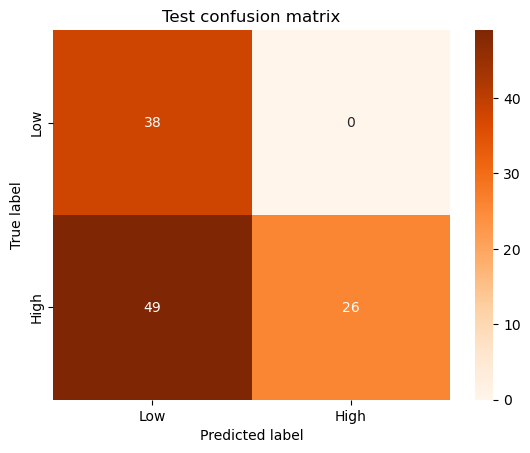

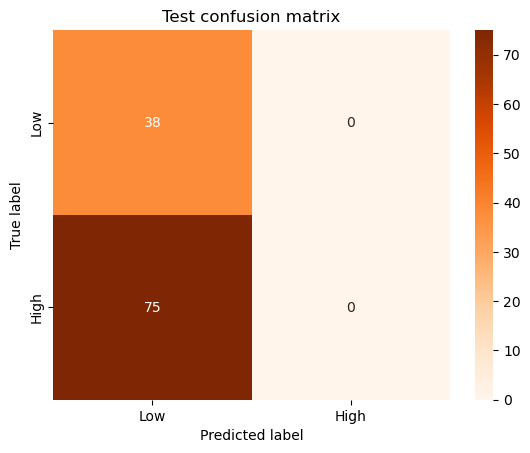

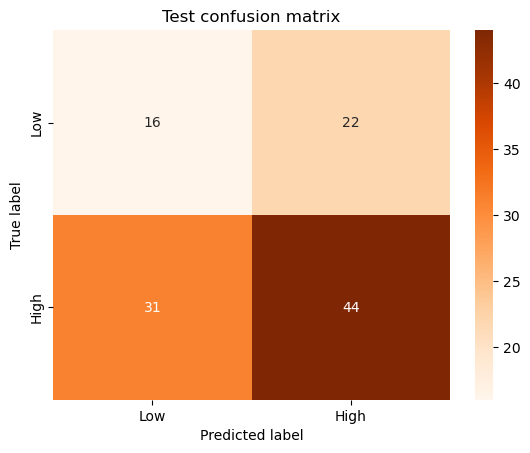

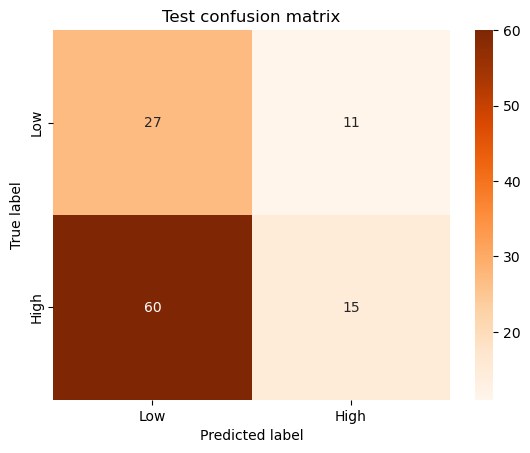

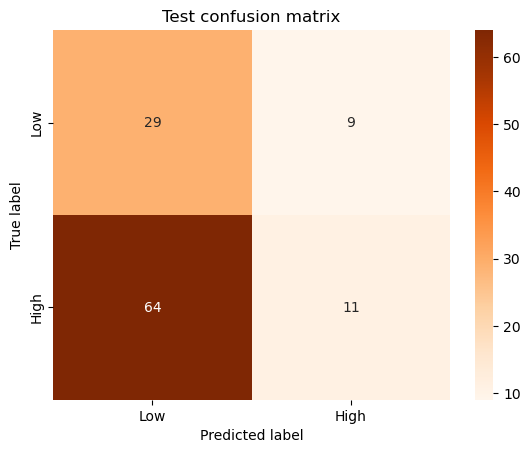

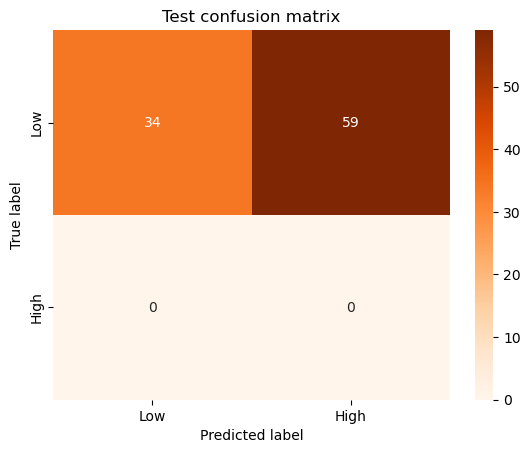

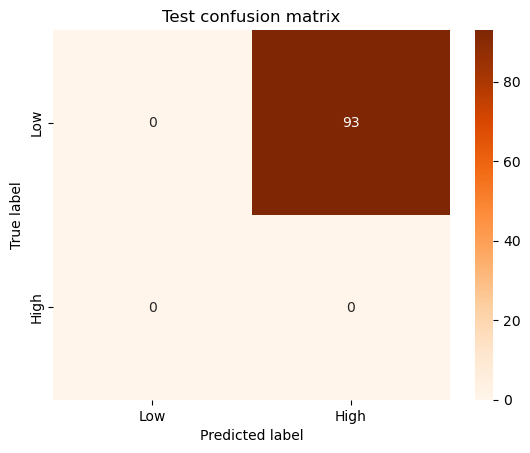

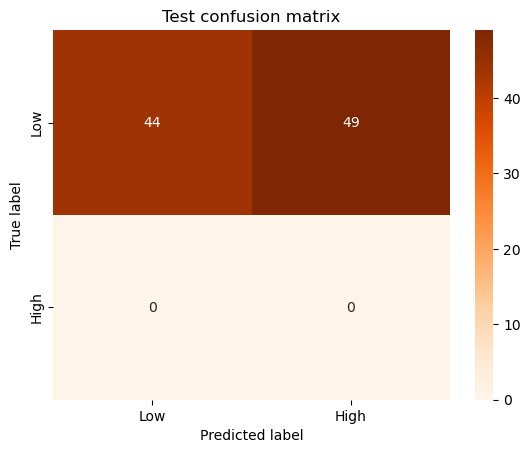

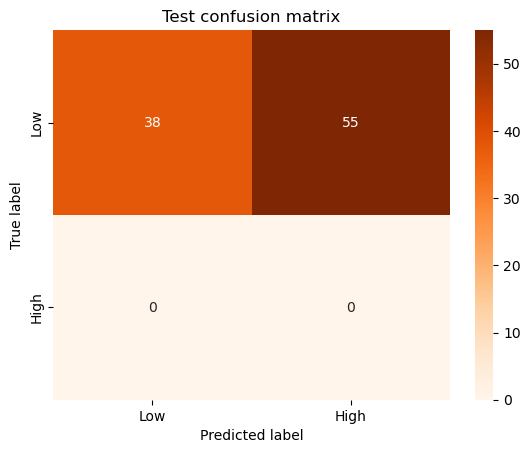

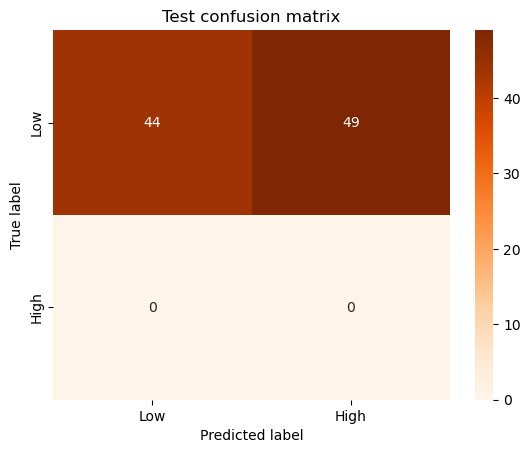

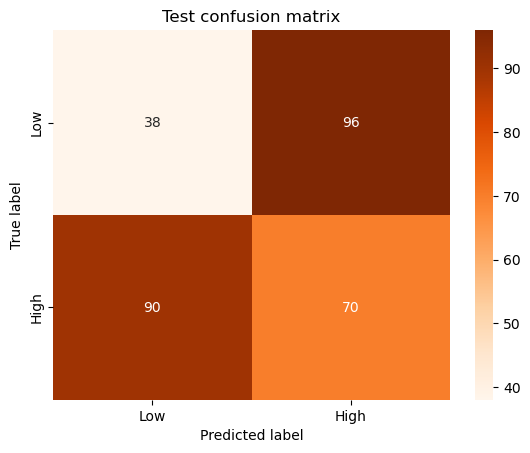

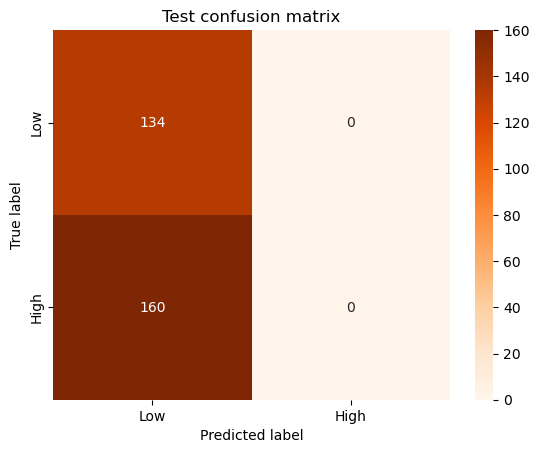

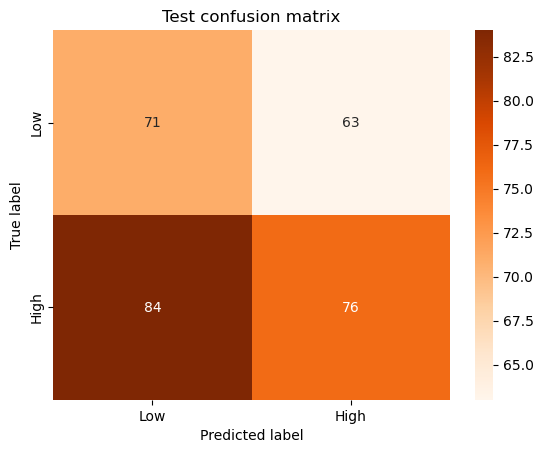

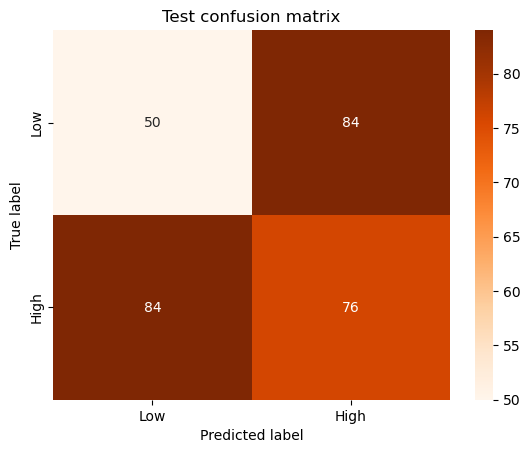

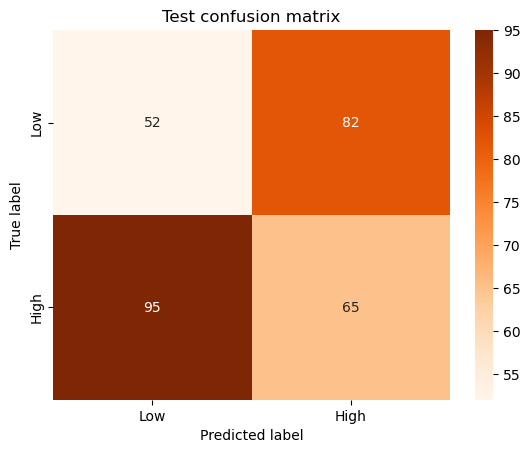

In [265]:
import numpy as np
import seaborn as sns
import pandas as pd
import random as rn
import os
import matplotlib.pyplot as plt
import xgboost as xgb
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
# from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier
# from sklearn.naive_bayes import BernoulliNB
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier

def plot_confusion_matrix(y_true, y_pred, classes=["Low", "High"]):
    cm = confusion_matrix(y_true, y_pred)
    fig = sns.heatmap(cm, annot=True, xticklabels=classes,
                      yticklabels=classes, cmap=plt.cm.Oranges, fmt='d')
    fig.set_xlabel("Predicted label")
    fig.set_ylabel("True label")
    fig.set_title("Test confusion matrix")
    
def models_run(metrics, X_train, y_train, X_test, y_test, split_array):
    if len(X_test) != 0:
        cm = plt.cm.RdBu
        cm_bright = ListedColormap(['#FF0000', '#0000FF']) 
        cm_path = ''

        if split_array[0] == 0:
            cm_path = '../dataset/raw/e4/confusion_matrices/LOAO/'
        elif split_array[0] == 1:
            cm_path = '../dataset/raw/e4/confusion_matrices/RCS/'
        elif split_array[0] == 2:
            cm_path = '../dataset/raw/e4/confusion_matrices/TRS/'

        if not os.path.exists(cm_path):
            os.makedirs(cm_path)

        # Getting distribution percentage for baseline models
        distr = (y_train.sum() + y_test.sum()) / (len(y_train) + len(y_test))
        print("Balance of positive (high) class distribution: ", distr)

        # Create the SVM model
        svm = SVC(kernel='linear')

        print("Model created")

        # Creating a grid for selecting best penalty for missclassified instances
        grid = {'C': [0.1, 1, 10, 100]}
        # Perform hyperparameter tuning theough grid search
        gs = GridSearchCV(svm, grid, cv=5)
        print("Started GridSearch")
        gs.fit(X_train, y_train)
        print("Best parameters: ", gs.best_params_)

        # Use the selected penalty term to create a better svm model
        new_svm = SVC(kernel='linear', C=gs.best_params_['C'])
        new_svm.fit(X_train, y_train)

        # Make predictions and assert model accuracy
        svm_preds = new_svm.predict(X_test)
        svm_accuracy = accuracy_score(y_test, svm_preds)
        svm_recall = recall_score(y_test, svm_preds)
        svm_precision = precision_score(y_test, svm_preds)
        metrics[0].append(svm_recall)
        metrics[1].append(svm_precision)
        metrics[2].append(svm_accuracy)
        print("SVM accuracy, recall and precision: ", svm_accuracy, svm_recall, svm_precision)
        plt.figure()
        plot_confusion_matrix(y_test, svm_preds)
        plt.savefig(cm_path + 'svm_' + split_array[1], bbox_inches='tight', pad_inches=0)

        # Create a majority random predict model as baseline model
        random_majority = DummyClassifier(strategy='most_frequent')
        random_majority.fit(X_train, y_train)
        rm_preds = random_majority.predict(X_test)
        rm_accuracy = accuracy_score(y_test, rm_preds)
        rm_recall = recall_score(y_test, rm_preds)
        rm_precision = precision_score(y_test, rm_preds)
        metrics[3].append(rm_recall)
        metrics[4].append(rm_precision)
        metrics[5].append(rm_accuracy)
        print("RM accuracy, recall and precision: ", rm_accuracy, rm_recall, rm_precision)
        plt.figure()
        plot_confusion_matrix(y_test, rm_preds)
        plt.savefig(cm_path + 'rm_' + split_array[1], bbox_inches='tight', pad_inches=0)

        # Create a random predict model as a baseline model
        random_model = DummyClassifier(strategy='uniform')
        random_model.fit(X_train, y_train)
        r_preds = random_model.predict(X_test)
        r_accuracy = accuracy_score(y_test, r_preds)
        r_recall = recall_score(y_test, r_preds)
        r_precision = precision_score(y_test, r_preds)
        metrics[6].append(r_recall)
        metrics[7].append(r_precision)
        metrics[8].append(r_accuracy)
        print("RC accuracy, recall and precision: ", r_accuracy, r_recall, r_precision)
        plt.figure()
        plot_confusion_matrix(y_test, r_preds)
        plt.savefig(cm_path + 'r_' + split_array[1], bbox_inches='tight', pad_inches=0)
        
        # Create an xgboost classifier
        xgb_classifier = xgb.XGBClassifier()
        xgb_classifier.fit(X_train, y_train)
        xgb_preds = xgb_classifier.predict(X_test)
        xgb_accuracy = accuracy_score(y_test, xgb_preds)
        xgb_recall = recall_score(y_test, xgb_preds)
        xgb_precision = precision_score(y_test, xgb_preds)
        metrics[9].append(xgb_recall)
        metrics[10].append(xgb_precision)
        metrics[11].append(xgb_accuracy)
        print("XGB accuracy, recall and precision: ", xgb_accuracy, xgb_recall, xgb_precision)
        plt.figure()
        plot_confusion_matrix(y_test, xgb_preds)
        plt.savefig(cm_path + 'xgb_' + split_array[1], bbox_inches='tight', pad_inches=0)
                                          
        # Create a Random Forest model
        rf_model = RandomForestClassifier()
        rf_model.fit(X_train, y_train)
        rf_preds = rf_model.predict(X_test)
        rf_accuracy = accuracy_score(y_test, rf_preds)
        rf_recall = recall_score(y_test, rf_preds)
        rf_precision = precision_score(y_test, rf_preds)
        metrics[12].append(rf_recall)
        metrics[13].append(rf_precision)
        metrics[14].append(rf_accuracy)
        print("RF accuracy, recall and precision: ", rf_accuracy, rf_recall, rf_precision)
        plt.figure()
        plot_confusion_matrix(y_test, rf_preds)
        plt.savefig(cm_path + 'rf_' + split_array[1], bbox_inches='tight', pad_inches=0)
                                      
# Create user ID array 
uid_arr = []
for i in range(20, 45):
    user = 'B' + str(i)
    uid_arr.append(user)

video_type = ['easy', 'medium' , 'hard']

# The SPLIT_TYPE variable controls what slit type is applied to the data and the ML models will be only run on it.
# 0 -> LOAO (leave-one-activity-out), a single user video is used as test set all the other videos are used as training set, this is done for each video of each user
# 1 -> Random Controlled Split, the test set is composed from a random selected video from each user, the process is then repeated other 2 times (once per video left)
# 2 -> Totally Random Split, the test set and the training set are randomly selected from all the data with a 80%-20% ratio
SPLIT_TYPE = 2

if SPLIT_TYPE == 0:
    metrics =[[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    for user in uid_arr:
        left_out_user = user
        for video in video_type:
            left_out_video = video
            non_left_vid_data = pd.DataFrame()
            left_vid_data = pd.read_csv('../dataset/raw/e4/video_features/' + video + '_features.csv')
            for vid in video_type:
                if vid != video:
                    data = pd.read_csv('../dataset/raw/e4/video_features/' + vid + '_features.csv')
                    non_left_vid_data = pd.concat([non_left_vid_data, data])
            # For now I kept the fill because the drop makes some user have no data and it causes the code to crash when their test set is selected (empty array)
            non_left_vid_data.dropna(inplace=True)
            left_vid_data.dropna(inplace=True)
            # non_left_vid_data.fillna(0, inplace=True)
            # left_vid_data.fillna(0, inplace=True)
            test_set = left_vid_data[left_vid_data['uid'] == user]
            non_test_set = left_vid_data[left_vid_data['uid'] != user]
            non_left_vid_data = pd.concat([non_left_vid_data, non_test_set])

            test_set.loc[test_set['recall_grade'] == 'high', 'recall_grade'] = 1
            test_set.loc[test_set['recall_grade'] == 'low', 'recall_grade'] = 0
            X_test = test_set[['hr_mean', 'HRV_BVP_sdnn', 'eda_stat_mean','eda_signal_overall_change', 'eda_power_peaks', 'st_mean', 'acc_f1', 'eda_st_corr']].values
            y_test = test_set['recall_grade']
            y_test = y_test.values.astype(np.float32)
            X_test, y_test = shuffle(X_test, y_test)

            non_left_vid_data.loc[non_left_vid_data['recall_grade'] == 'high', 'recall_grade'] = 1
            non_left_vid_data.loc[non_left_vid_data['recall_grade'] == 'low', 'recall_grade'] = 0
            X_train = non_left_vid_data[['hr_mean', 'HRV_BVP_sdnn', 'eda_stat_mean','eda_signal_overall_change', 'eda_power_peaks', 'st_mean', 'acc_f1', 'eda_st_corr']].values
            y_train = non_left_vid_data['recall_grade']
            y_train = y_train.values.astype(np.float32)
            X_train, y_train = shuffle(X_train, y_train)
            print("Data split performed")
            split_array = [SPLIT_TYPE, '_' + left_out_user + '_' + left_out_video + '_cm.png']
            models_run(metrics, X_train, y_train, X_test, y_test, split_array)
    print("Accuracy of SVM across all the runs: ", np.mean(metrics[2]))
    print("Accuracy of Random Majority Classifier across all the runs: ", np.mean(metrics[5]))
    print("Accuracy of Random Classifier across all the runs: ", np.mean(metrics[8]))
    print("Accuracy of XGBoost Classifier across all the runs: ", np.mean(metrics[11]))
    print("Accuracy of Random Forest Classifier across all the runs: ", np.mean(metrics[14]))
    
    print("Recall of SVM across all the runs: ", np.mean(metrics[0]))
    print("Recall of Random Majority Classifier across all the runs: ", np.mean(metrics[3]))
    print("Recall of Random Classifier across all the runs: ", np.mean(metrics[6]))
    print("Recall of XGBoost Classifier across all the runs: ", np.mean(metrics[9]))
    print("Recall of Random Forest Classifier across all the runs: ", np.mean(metrics[12]))
    
    print("Precision of SVM across all the runs: ", np.mean(metrics[1]))
    print("Precision of Random Majority Classifier across all the runs: ", np.mean(metrics[4]))
    print("Precision of Random Classifier across all the runs: ", np.mean(metrics[7]))
    print("Precision of XGBoost Classifier across all the runs: ", np.mean(metrics[10]))
    print("Precision of Random Forest Classifier across all the runs: ", np.mean(metrics[13]))

elif SPLIT_TYPE == 1:
    user_videos_dict = {}
    for uid in uid_arr:
        user_videos_dict[uid] = [0, 0, 0]
    # Each inner array represents a metric for a model (e.g. svm_recall
    metrics = [[],[],[],[],[],[],[],[],[], [], [],[],[],[],[]]
    for i in range(len(video_type)):
        test_set = pd.DataFrame()
        train_set = pd.DataFrame()
        video_combination = ''
        for user in uid_arr:
            valid_indexes = [index for index in range(len(user_videos_dict[user])) if user_videos_dict[user][index] == 0]
            random_selector = rn.choice(valid_indexes)
            video_combination = video_combination + str(random_selector)
            user_videos_dict[user][random_selector] = 1
            video_selected = video_type[random_selector]
            test_data = pd.read_csv('../dataset/raw/e4/video_features/' + video_selected + '_features.csv')
            test_data.dropna(inplace=True)
            valid_data = test_data[test_data['uid'] == user]
            valid_data.loc[valid_data['recall_grade'] == 'high', 'recall_grade'] = 1
            valid_data.loc[valid_data['recall_grade'] == 'low', 'recall_grade'] = 0
            test_set = pd.concat([test_set, valid_data])
            for video in video_type:
                if video != video_selected:
                    train_data = pd.read_csv('../dataset/raw/e4/video_features/' + video + '_features.csv')
                    train_data.dropna(inplace=True)
                    valid_data = train_data[train_data['uid'] == user]
                    valid_data.loc[valid_data['recall_grade'] == 'high', 'recall_grade'] = 1
                    valid_data.loc[valid_data['recall_grade'] == 'low', 'recall_grade'] = 0
                    train_set = pd.concat([train_set, valid_data])
        X_train = train_set[['hr_mean', 'HRV_BVP_sdnn', 'eda_stat_mean','eda_signal_overall_change', 'eda_power_peaks', 'st_mean', 'acc_f1', 'eda_st_corr']].values
        y_train = train_set['recall_grade']
        y_train = y_train.values.astype(np.float32)
        X_test = test_set[['hr_mean', 'HRV_BVP_sdnn', 'eda_stat_mean','eda_signal_overall_change', 'eda_power_peaks', 'st_mean', 'acc_f1', 'eda_st_corr']].values
        y_test = test_set['recall_grade']
        y_test = y_test.values.astype(np.float32)
        X_test, y_test = shuffle(X_test, y_test)
        X_train, y_train = shuffle(X_train, y_train)
        print("Data split performed")
        split_array = [SPLIT_TYPE, '_' + video_combination + '_cm.png']
        models_run(metrics, X_train, y_train, X_test, y_test, split_array)
    print("Accuracy of SVM across all the runs: ", np.mean(metrics[2]))
    print("Accuracy of Random Majority Classifier across all the runs: ", np.mean(metrics[5]))
    print("Accuracy of Random Classifier across all the runs: ", np.mean(metrics[8]))
    print("Accuracy of XGBoost Classifier across all the runs: ", np.mean(metrics[11]))
    print("Accuracy of Random Forest Classifier across all the runs: ", np.mean(metrics[14]))
    
    print("Recall of SVM across all the runs: ", np.mean(metrics[0]))
    print("Recall of Random Majority Classifier across all the runs: ", np.mean(metrics[3]))
    print("Recall of Random Classifier across all the runs: ", np.mean(metrics[6]))
    print("Recall of XGBoost Classifier across all the runs: ", np.mean(metrics[9]))
    print("Recall of Random Forest Classifier across all the runs: ", np.mean(metrics[12]))
    
    print("Precision of SVM across all the runs: ", np.mean(metrics[1]))
    print("Precision of Random Majority Classifier across all the runs: ", np.mean(metrics[4]))
    print("Precision of Random Classifier across all the runs: ", np.mean(metrics[7]))
    print("Precision of XGBoost Classifier across all the runs: ", np.mean(metrics[10]))
    print("Precision of Random Forest Classifier across all the runs: ", np.mean(metrics[13]))

elif SPLIT_TYPE == 2:
    metrics = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    # This is the TEST SET users percentage
    percentage = 20
    users_number = len(uid_arr) * percentage // 100
    users_dict = {}
    for user in uid_arr:
        users_dict[user] = 0
    for i in range(5):
        user_remaining = []
        for user, tested in users_dict.items():
            if tested == 0:
                user_remaining.append(user)
        data = pd.DataFrame()
        for video in video_type:
            tmp_data = pd.read_csv('../dataset/raw/e4/video_features/' + video + '_features.csv')
            tmp_data.dropna(inplace=True)
            tmp_data.loc[tmp_data['recall_grade'] == 'high', 'recall_grade'] = 1
            tmp_data.loc[tmp_data['recall_grade'] == 'low', 'recall_grade'] = 0
            data = pd.concat([data, tmp_data])
        indexes = rn.sample(range(len(user_remaining)), users_number)
        selected_users = []
        for idx in indexes:
            selected_users.append(user_remaining[idx])
        test_set = pd.DataFrame()
        users_string = ''
        for user in selected_users:
            users_dict[user] = 1
            users_string = users_string + user
            test_data = data[data['uid'] == user]
            test_set = pd.concat([test_set, test_data])
            data.drop(data[data['uid'] == user].index, inplace=True)
        X_train = data[['hr_mean', 'HRV_BVP_sdnn', 'eda_stat_mean','eda_signal_overall_change', 'eda_power_peaks', 'st_mean', 'acc_f1', 'eda_st_corr']].values
        y_train = data['recall_grade']
        y_train = y_train.values.astype(np.float32)
        X_train, y_train = shuffle(X_train, y_train)
        X_test = test_set[['hr_mean', 'HRV_BVP_sdnn', 'eda_stat_mean','eda_signal_overall_change', 'eda_power_peaks', 'st_mean', 'acc_f1', 'eda_st_corr']].values
        y_test = test_set['recall_grade']
        y_test = y_test.values.astype(np.float32)
        X_test, y_test = shuffle(X_test, y_test)
        print("Data split performed")
        split_array = [SPLIT_TYPE, '_' + users_string + '_cm.png']
        models_run(metrics, X_train, y_train, X_test, y_test, split_array)
    print("Accuracy of SVM across all the runs: ", np.mean(metrics[2]))
    print("Accuracy of Random Majority Classifier across all the runs: ", np.mean(metrics[5]))
    print("Accuracy of Random Classifier across all the runs: ", np.mean(metrics[8]))
    print("Accuracy of XGBoost Classifier across all the runs: ", np.mean(metrics[11]))
    print("Accuracy of Random Forest Classifier across all the runs: ", np.mean(metrics[14]))
    
    print("Recall of SVM across all the runs: ", np.mean(metrics[0]))
    print("Recall of Random Majority Classifier across all the runs: ", np.mean(metrics[3]))
    print("Recall of Random Classifier across all the runs: ", np.mean(metrics[6]))
    print("Recall of XGBoost Classifier across all the runs: ", np.mean(metrics[9]))
    print("Recall of Random Forest Classifier across all the runs: ", np.mean(metrics[12]))
    
    print("Precision of SVM across all the runs: ", np.mean(metrics[1]))
    print("Precision of Random Majority Classifier across all the runs: ", np.mean(metrics[4]))
    print("Precision of Random Classifier across all the runs: ", np.mean(metrics[7]))
    print("Precision of XGBoost Classifier across all the runs: ", np.mean(metrics[10]))
    print("Precision of Random Forest Classifier across all the runs: ", np.mean(metrics[13]))
    